In [1]:
from typing import override

import dnnlpy
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from dnnlpy.models.mlp import Module

rng = np.random.default_rng(42)
dnnlpy.set_matplotlib_format('svg')
print("Numpy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)

Numpy version: 2.5.2
Matplotlib version: 3.11.1


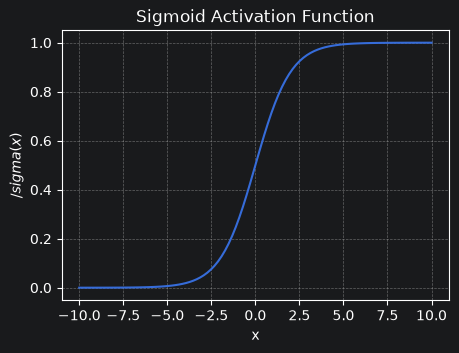

In [2]:
"""
Sigmoid 激活函数
    缺点: 当输入非常大或者非常小时,输出会非常接近1,0,此时导数也接近0 导致梯度消失
"""


def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-x))


x = np.linspace(-10, 10, 100)
y = sigmoid(x)

fig = plt.figure(1, figsize=(5, 3.5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(x, y)
ax.grid(linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel(r'$/sigma(x)$')
ax.set_title('Sigmoid Activation Function')
plt.show()


class Sigmoid(Module):
    def __init__(self):
        super().__init__()

    @override
    def forward(self, x: np.ndarray) -> np.ndarray:
        self.ctx = sigmoid(x)
        return self.ctx

    @override
    def backward(self, grad: np.ndarray) -> np.ndarray:
        assert self.ctx is not None, "Must call  forward  before backward"
        return grad * self.ctx * (1 - self.ctx)


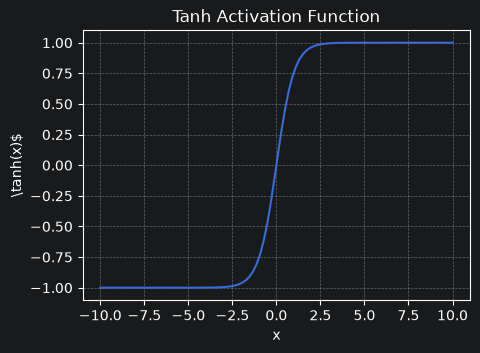

In [4]:
"""
Tanh激活函数
    缺点: 数值的绝对值很大时,输出接近-1,或者1 导致导数为0 梯度消失

"""


def tanh(x: np.ndarray) -> np.ndarray:
    return np.tanh(x)


x = np.linspace(-10, 10, 100)
y = tanh(x)

fig = plt.figure(2, figsize=(5, 3.5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(x, y)
ax.grid(linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel(r'\tanh(x)$')
ax.set_title('Tanh Activation Function')
plt.show()


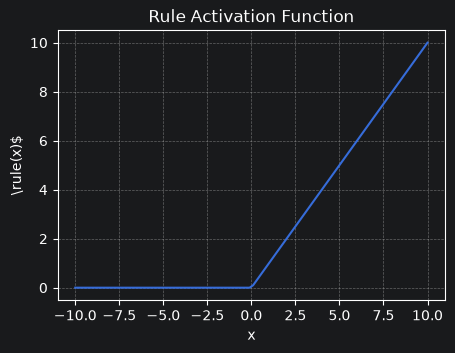

In [5]:
"""
Relu激活函数
    缺点:神经元如果长期处于负半轴,对应的梯度一致为0,参数很难被更新
"""


def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0, x)


x = np.linspace(-10, 10, 100)
y = relu(x)

fig = plt.figure(2, figsize=(5, 3.5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(x, y)
ax.grid(linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel(r'\rule(x)$')
ax.set_title('Rule Activation Function')
plt.show()


class ReLuWithMask(Module):
    def __init__(self):
        super().__init__()

    @override
    def forward(self, x: np.ndarray) -> np.ndarray:
        self.ctx = x > 0
        return self.ctx * x

    @override
    def backward(self, grad: np.ndarray) -> np.ndarray:
        assert self.ctx is not None, "Must call  forward  before backward"
        return grad * self.ctx

